In [0]:
%sql
CREATE OR REPLACE TABLE workspace.gold.ml_features_bad_review AS
WITH item_main AS (          -- categoría y seller del ítem más caro de la orden
  SELECT s.order_id,
         max_by(p.category, s.price)  AS main_category,
         max_by(s.seller_id, s.price) AS main_seller_id
  FROM workspace.gold.fact_sales s
  JOIN workspace.gold.dim_product p ON s.product_id = p.product_id
  GROUP BY s.order_id
)
SELECT o.order_id,
       o.date_key,
       o.order_value, o.freight_value,
       round(o.freight_value / nullif(o.order_value, 0), 3)        AS freight_ratio,
       o.items_qty, o.sellers_qty, o.max_installments, o.main_payment_type,
       datediff(so.estimated_delivery_ts, so.purchase_ts)          AS promised_days,
       o.delivery_days, o.delivery_delay_days,
       i.main_category,
       cu.state AS customer_state, sl.state AS seller_state,
       CAST(cu.state = sl.state AS INT)                            AS same_state,
       round(2 * 6371 * asin(sqrt(
             pow(sin(radians(sl.lat - gc.lat) / 2), 2) +
             cos(radians(gc.lat)) * cos(radians(sl.lat)) *
             pow(sin(radians(sl.lng - gc.lng) / 2), 2))), 1)       AS distance_km,
       CAST(o.is_bad_review AS INT)                                AS label
FROM workspace.gold.fact_orders o
JOIN workspace.silver.orders so    ON o.order_id = so.order_id
JOIN workspace.silver.customers cu ON so.customer_id = cu.customer_id
LEFT JOIN workspace.silver.geolocation gc ON cu.zip_prefix = gc.zip_prefix
JOIN item_main i                   ON o.order_id = i.order_id
JOIN workspace.gold.dim_seller sl  ON i.main_seller_id = sl.seller_id
WHERE o.order_status = 'delivered'
  AND o.review_score IS NOT NULL
  AND o.delivery_days IS NOT NULL;

num_affected_rows,num_inserted_rows


(95824, 18)
% reviews malas: 12.8%


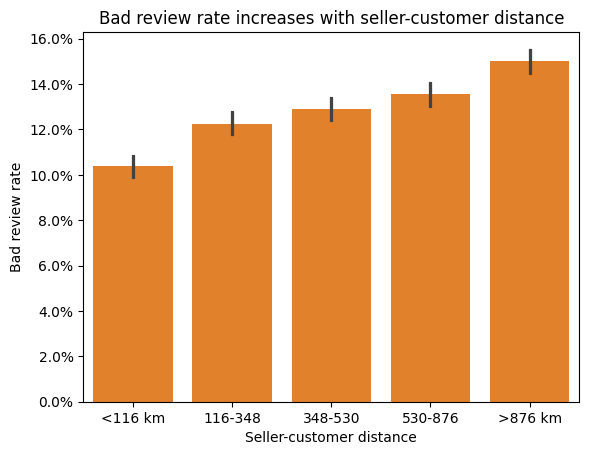

In [0]:
# %pip install seaborn

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = spark.table("workspace.gold.ml_features_bad_review").toPandas()
df["date_key"] = pd.to_datetime(df["date_key"])

print(df.shape)
print(f"% reviews malas: {df['label'].mean():.1%}")

df["distance_bucket"] = pd.qcut(df["distance_km"], 5)
sns.barplot(data=df, x="distance_bucket", y="label")
from matplotlib.ticker import PercentFormatter
labels = ["<116 km", "116-348", "348-530", "530-876", ">876 km"]
ax = sns.barplot(data=df, x="distance_bucket", y="label")
ax.set_xticks(range(len(labels)), labels)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set(xlabel="Seller-customer distance", ylabel="Bad review rate",
       title="Bad review rate increases with seller-customer distance")
plt.show()

In [0]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = ["order_value", "freight_value", "freight_ratio", "items_qty", "sellers_qty",
            "max_installments", "promised_days", "delivery_days", "delivery_delay_days",
            "same_state", "distance_km"]
cat_cols = ["main_payment_type", "main_category", "customer_state", "seller_state"]
features = num_cols + cat_cols

cutoff = "2018-05-01"                          # entrenar con el pasado, evaluar con el futuro
train, test = df[df.date_key < cutoff], df[df.date_key >= cutoff]
X_train, y_train = train[features], train["label"]
X_test,  y_test  = test[features],  test["label"]
print(f"train: {len(train):,} | test: {len(test):,}")

preprocess = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc",  StandardScaler())]), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore",
                                            min_frequency=50, sparse_output=False))]), cat_cols),
])

train: 70,582 | test: 25,242


In [0]:
import mlflow
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, precision_score

mlflow.sklearn.autolog(log_models=True)

candidates = {
    "logistic_regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "hist_gradient_boosting": HistGradientBoostingClassifier(class_weight="balanced",
                                                             max_iter=300, learning_rate=0.05,
                                                             random_state=42),
}

results = {}
for name, model in candidates.items():
    with mlflow.start_run(run_name=name) as run:
        pipe = Pipeline([("prep", preprocess), ("model", model)])
        pipe.fit(X_train, y_train)

        proba = pipe.predict_proba(X_test)[:, 1]
        pred  = (proba >= 0.5).astype(int)
        metrics = {
            "test_roc_auc":   roc_auc_score(y_test, proba),
            "test_pr_auc":    average_precision_score(y_test, proba),
            "test_recall":    recall_score(y_test, pred),
            "test_precision": precision_score(y_test, pred),
        }
        mlflow.log_metrics(metrics)
        results[name] = {"pipe": pipe, "run_id": run.info.run_id, **metrics}

pd.DataFrame(results).T.drop(columns="pipe")

2026/09/28 21:01:48 WARNING mlflow.models.signature: Failed to infer schema for inputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. Note that MLflow doesn't validate data types during inference for AnyType. To see the full traceback, set logging level to DEBUG.
🔗 View Logged Model at: https://dbc-cdb0dfbc-3e36.cloud.databricks.com/ml/experiments/1069731523158764/models/m-bb6da425ef644b9183b7fd6eace6d5df?o=7474659102524531
2026/09/28 21:02:12 WARNING mlflow.models.signature: Failed to infer schema for inputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. Note that MLflow doesn't validate data types during inference for AnyType. To see the full traceback, set logging level to DEBUG.
🔗 View Logged Model at: https://dbc-cdb0dfbc-3e36.cloud.databricks.com/ml/experiments/1069731523158764/models/m-fffa671aed5848329206dfdcf78873bd?o=7474659102524531


,run_id,test_roc_auc,test_pr_auc,test_recall,test_precision
logistic_regression,fe17611fdbae4d8884c46c54d80f57f4,0.692288,0.258534,0.376634,0.276856
hist_gradient_boosting,04f70f89cd9545bd9cedbffab0774836,0.701353,0.328385,0.42099,0.309642


Best model: hist_gradient_boosting


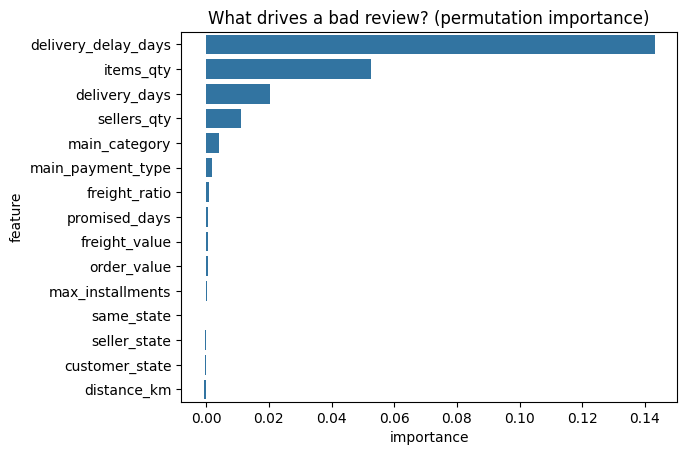

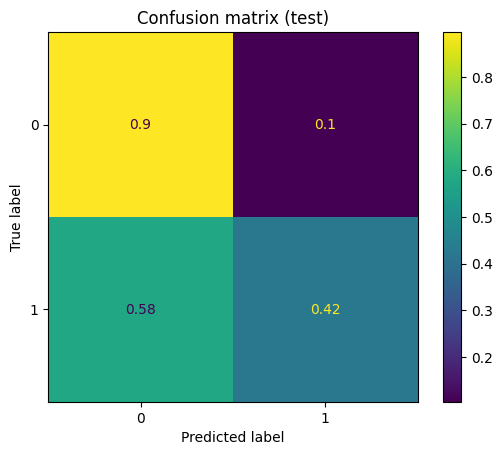

In [0]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay

assert "results" in globals(), "Corré primero las celdas 2, 3 y 4 (Run all above)"

best_name = max(results, key=lambda k: results[k]["test_pr_auc"])
best = results[best_name]["pipe"]
print("Best model:", best_name)

# Muestra de test para acelerar el cálculo (mismo resultado en la práctica)
sample = X_test.sample(n=min(8000, len(X_test)), random_state=42)
y_sample = y_test.loc[sample.index]

imp = permutation_importance(best, sample, y_sample, scoring="average_precision",
                             n_repeats=5, random_state=42)
imp_df = (pd.DataFrame({"feature": features, "importance": imp.importances_mean})
            .sort_values("importance", ascending=False))

sns.barplot(data=imp_df, x="importance", y="feature")
plt.title("What drives a bad review? (permutation importance)"); plt.show()

ConfusionMatrixDisplay.from_estimator(best, X_test, y_test, normalize="true")
plt.title("Confusion matrix (test)"); plt.show()

### Model interpretation

**What drives a bad review?**
- **Delivery delay is by far the strongest driver**: shuffling it drops PR-AUC by ~0.14 (from ~0.33 to ~0.19).
- **Order complexity matters**: orders with more items (`items_qty`) or multiple sellers (`sellers_qty`) are more likely to get a bad review, possibly because they ship in separate packages and arrive incomplete (hypothesis to validate with review comments).
- **Distance adds no information once delivery time is known**: the earlier distance-vs-reviews correlation is explained by longer, less reliable deliveries (correlation ≠ causation).
- **Payment method and installments do not predict satisfaction.**

**Confusion matrix (test set, threshold 0.5)**
- 90% of good reviews are correctly classified (10% false alarms).
- 42% of bad reviews are detected (recall); the remaining 58% likely stem from causes not captured in the data (product quality, wrong item).
- Lowering the threshold would increase recall at the cost of more false alarms; the right value depends on the cost of a voucher vs. a lost customer.